Everytime you want to check the high energy (HE) scale with Thorium data, you first need to create two files:

- 3D map with $^{83\text{m}}\text{Kr}$ data previous to HE calibration campaign.
- H5 file with energy scale time evolution within the HE calibration campaign.

__NOTE:__ _this is valid until we get more details about Zemrude city._

In [8]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# Styling Plot
crudo.pt.ccortesp_plot_style()

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Preliminary

In [25]:
# --- DIRECTORIES
ICAROS_LOW_BCKG_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/Low_background/2025/'
ICAROS_HE_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/HE_calibration/2025/'
OUTPUT_DIR = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/'

# --- FILES
# RUNS_TO_COMBINE = [15546, 15547, 15557]      # Low-background runs to combine their maps
RUNS_TO_COMBINE = [15730, 15731, 15732, 15733, 15734, 15735, 15736, 15737]
RUNS_FOR_ENERGY_SCALE = [15589]              # HE calibration runs to use for energy scale time evolution

# --- FUNCTIONS
def merge_bins(df):
    """
    Merges data for a single bin (voxel) using a weighted average.
    """
    new_n  = df.nevents.sum()
    new_mu = np.sum(df.mu * df.nevents) / np.clip(new_n, 1, None)
    return pd.Series({'nevents': new_n, 'mu': new_mu})
    # pd.DataFrame(dict(mu=new_mu, nevents=new_n), index=[0])
                       

def combine_maps(maps_list: list) -> pd.DataFrame:
    """
    Combines a list of Kr map DataFrames into a single, high-statistics map.
    """
    full_map = pd.concat(maps_list, ignore_index=True)
    voxel_id_columns = ['k', 'i', 'j', 'dt', 'x', 'y']      # Columns that define a unique voxel. Zemrude includes news.

    combined_map = full_map.groupby(voxel_id_columns).apply(merge_bins).reset_index()
    return combined_map

def create_full_h5_scale(scale_list):
    """
    Combines a list of Kr time evolution DataFrames into a single DataFrame.
    It contains the time evolution of the energy scale (or yield) S2e.
    """
    full_scale = pd.concat(scale_list, ignore_index=True)
    combined_scale = full_scale[['run_number', 'ts', 's2e', 's2eu']].rename(columns={'run_number': 'run', 'ts': 'time'})
    return combined_scale

### Testing

In [ ]:
# Icaros 2025
# test_file = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/energy_scale_he.h5'
# test_file = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/combined_15546_15557.map3d'

# Zemrude 2026
test_file = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/combined_15546_15557_zemrude_map.h5'

test_df = pd.read_hdf(test_file, key='/krmap')       # Options as key: 'krmap', 'data'
test_df

,dt,x,y,level_3,mu,nevents
0,86.5,-445.5,-445.5,0,0.0,0.0
1,86.5,-445.5,-436.5,0,0.0,0.0
2,86.5,-445.5,-427.5,0,0.0,0.0
3,86.5,-445.5,-418.5,0,0.0,0.0
4,86.5,-445.5,-409.5,0,0.0,0.0
...,...,...,...,...,...,...
99995,1283.5,445.5,409.5,0,0.0,0.0
99996,1283.5,445.5,418.5,0,0.0,0.0
99997,1283.5,445.5,427.5,0,0.0,0.0
99998,1283.5,445.5,436.5,0,0.0,0.0


# Combine 3D Map

In [26]:
# List of maps to combine
list_maps_h5 = []

for file in os.listdir(ICAROS_LOW_BCKG_DIR):

    if any(str(run) in file for run in RUNS_TO_COMBINE) and 'zemrude' in file:

        filename = os.path.join(ICAROS_LOW_BCKG_DIR, file)
        print(f"{os.path.basename(filename)} map will be combined.")
        print(filename)

        df = pd.read_hdf(filename, key='krmap/krmap')
        list_maps_h5.append(df)

run_15731.zemrude-test-2-gfd7dd555.20250717-26-g211f149.KrDesman.zemrude.h5 map will be combined.
/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/Low_background/2025/run_15731.zemrude-test-2-gfd7dd555.20250717-26-g211f149.KrDesman.zemrude.h5
run_15734.zemrude-test-2-gfd7dd555.20250717-26-g211f149.KrDesman.zemrude.h5 map will be combined.
/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/Low_background/2025/run_15734.zemrude-test-2-gfd7dd555.20250717-26-g211f149.KrDesman.zemrude.h5
run_15735.zemrude-test-2-gfd7dd555.20250717-26-g211f149.KrDesman.zemrude.h5 map will be combined.
/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/Low_background/2025/run_15735.zemrude-test-2-gfd7dd555.20250717-26-g211f149.KrDesman.zemrude.h5
run_15736.zemrude-test-2-gfd7dd555.20250717-26-g211f149.KrDesman.zemrude.h5 map will be combined.
/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/Low_background/2025/run_15736.zemrude-test-2-gfd7dd5

In [27]:
# Combine the maps using the weighted average functions
combined_map_df = combine_maps(list_maps_h5)
print("Combination complete.")

# Save the combined map to a HDF5 file
output_filename = f'combined_{RUNS_TO_COMBINE[0]}_{RUNS_TO_COMBINE[-1]}_zemrude_map.h5'
print(f"\nSaving combined map to: {os.path.join(OUTPUT_DIR, output_filename)}")
combined_map_df.to_hdf(os.path.join(OUTPUT_DIR, output_filename), key='krmap/krmap', mode='w', format='table')
print("Done.")

Combination complete.

Saving combined map to: /lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/combined_15730_15737_zemrude_map.h5
Done.


How does it look?

In [28]:
combined_map_df

,k,i,j,dt,x,y,nevents,mu
0,0,0,0,86.5,-445.5,-445.5,0.0,0.0
1,0,0,1,86.5,-445.5,-436.5,0.0,0.0
2,0,0,2,86.5,-445.5,-427.5,0.0,0.0
3,0,0,3,86.5,-445.5,-418.5,0.0,0.0
4,0,0,4,86.5,-445.5,-409.5,0.0,0.0
...,...,...,...,...,...,...,...,...
99995,9,99,95,1283.5,445.5,409.5,0.0,0.0
99996,9,99,96,1283.5,445.5,418.5,0.0,0.0
99997,9,99,97,1283.5,445.5,427.5,0.0,0.0
99998,9,99,98,1283.5,445.5,436.5,0.0,0.0


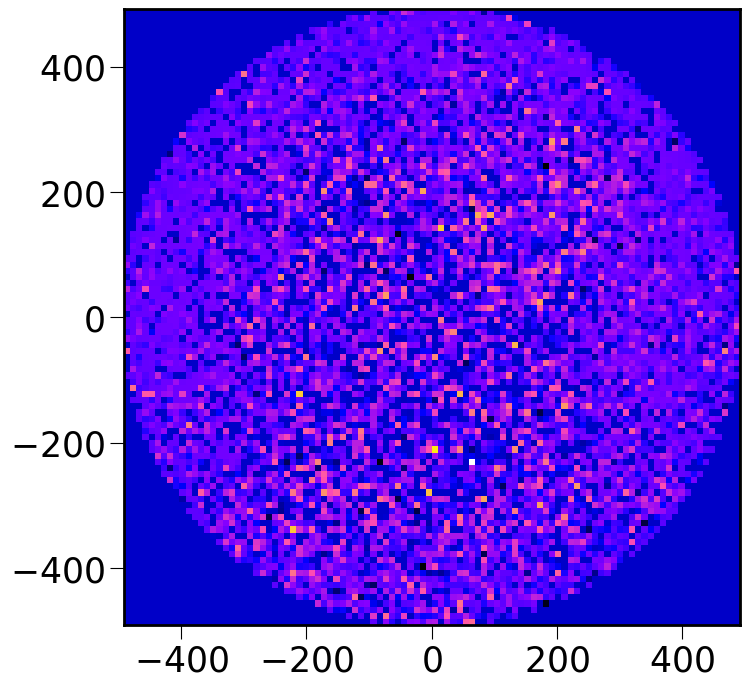

In [29]:
# Let's look close to the anode
combined_map_df = combined_map_df[combined_map_df['k'] == 0].copy()
plt.imshow(combined_map_df['mu'].values.reshape(100, 100).T, extent=(-crudo.pt.N100_rad, crudo.pt.N100_rad,-crudo.pt.N100_rad, crudo.pt.N100_rad))

# Energy Scale Evolution

In [8]:
# List of h5 files to use for energy scale time evolution
list_scale_h5 = []

for file in os.listdir(ICAROS_HE_DIR):

    if any(str(run) in file for run in RUNS_FOR_ENERGY_SCALE) and 'zemrude' in file:

        filename = os.path.join(ICAROS_HE_DIR, file)
        print(f"{os.path.basename(filename)} file will be used.")

        df = pd.read_hdf(filename, key='t_evol/t_evol')
        list_scale_h5.append(df)

run_15589.zemrude-test-4-g677d7f98.20250717-26-g211f149.KrDesman.zemrude.h5 file will be used.


In [23]:
# Combine the energy scale dataframes
combined_scale_df = create_full_h5_scale(list_scale_h5)
print("Combination complete.")

# Save the combined file to a HDF5 file
output_filename = f'energy_scale_{RUNS_FOR_ENERGY_SCALE[0]}_{RUNS_FOR_ENERGY_SCALE[-1]}_he.h5'
print(f"\nSaving combined map to: {os.path.join(OUTPUT_DIR, output_filename)}")
combined_scale_df.to_hdf(os.path.join(OUTPUT_DIR, output_filename), key='data', mode='w', format='table')
print("Done.")

Combination complete.

Saving combined map to: /lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/energy_scale_15589_15589_he.h5
Done.
